<a href="https://colab.research.google.com/github/aniketpathak028/computer-vision/blob/main/autoencoder_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

implementing a basic autoencoder from scratch!

In [1]:
# import libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# defining the device
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# data into train and val

BATCH_SIZE=128
data_transform= transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True, transform=data_transform, download= True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle= True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 44.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 9.36MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 108MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.01MB/s]


In [18]:
from torch.nn.modules.activation import ReLU
# defining the autoencoder class

class AutoEncoder(nn.Module):
  def __init__(self, latent_dim=1, hidden_dim=256):
    super().__init__()

    #Encoder
    self.encoder= nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU()
    )

    #Decoder
    self.decoder= nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 784),
        nn.Sigmoid()
    )

  def forward(self, x):
    z= self.encoder(x)
    x_reconstructed = self.decoder(z)
    return x_reconstructed

In [19]:
# defining the model and the loss

model= AutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [20]:
epochs= 5

model.train()
for epoch in range(epochs):
  total_loss= 0
  for x, _ in train_loader:
    x= x.view(-1, 784).to(device)

    optimizer.zero_grad()
    x_recon= model(x)
    loss= criterion(x_recon, x)
    loss.backward()
    optimizer.step()

    total_loss = total_loss + loss.item()
  avg_loss= total_loss / len(train_loader)
  print(f"Epoch [{epoch+1}/{epochs}], Loss:{avg_loss:.6f}")

Epoch [1/5], Loss:0.072387
Epoch [2/5], Loss:0.067395
Epoch [3/5], Loss:0.067369
Epoch [4/5], Loss:0.067367
Epoch [5/5], Loss:0.067361


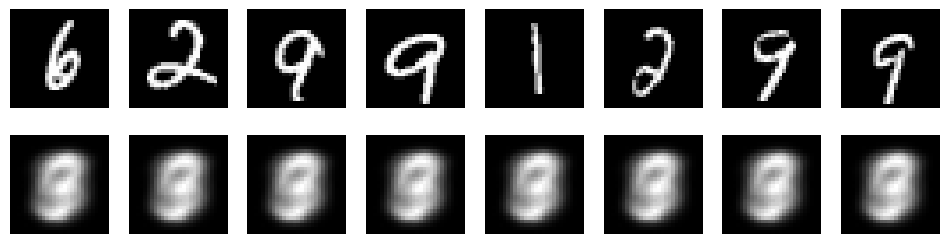

In [21]:
# evaluation

model.eval()
with torch.no_grad():
  x, _ = next(iter(train_loader))
  x = x.view(-1, 784).to(device)
  x_recon= model(x)

  n= 8
  plt.figure(figsize=(12,3))

  for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28,28), cmap="gray")
    plt.axis("off")

    plt.subplot(2, n, i+1+n)
    plt.imshow(x_recon[i].view(28,28), cmap="gray")
    plt.axis("off")

  plt.show()


In [22]:
model.eval()

latents=[]
labels=[]

with torch.no_grad():
  for x, y in train_loader:
    x= x.view(-1, 784).to(device)
    z= model.encoder(x)

    latents.append(z.cpu())
    labels.append(y)

latents= torch.cat(latents, dim=0)
labels= torch.cat(labels, dim=0)

Detected Latent Dimension: 1


/tmp/ipykernel_7607/1983910574.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


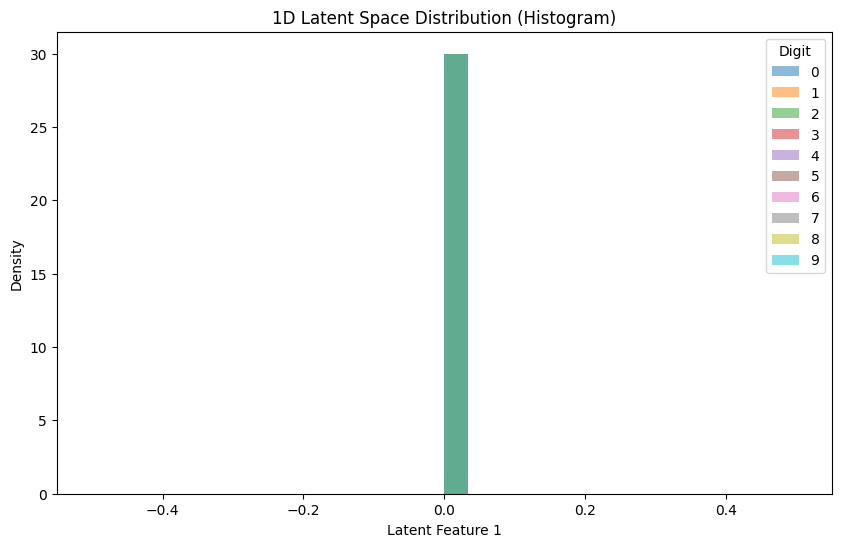

In [24]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import torch


def plot_latent_space(latents, labels):
    # Convert PyTorch tensors to NumPy arrays
    if isinstance(latents, torch.Tensor):
        latents = latents.numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.numpy()

    latent_dim = latents.shape[1]
    print(f"Detected Latent Dimension: {latent_dim}")

    # Setup color map for MNIST digits (0-9)
    cmap = plt.cm.get_cmap('tab10', 10)

    # -------------------------------------------------------------
    # Condition 1: 1D Space -> Histogram
    # -------------------------------------------------------------
    if latent_dim == 1:
        plt.figure(figsize=(10, 6))
        for digit in range(10):
            mask = labels == digit
            plt.hist(latents[mask, 0], bins=30, alpha=0.5, label=str(digit), density=True)
        plt.title("1D Latent Space Distribution (Histogram)")
        plt.xlabel("Latent Feature 1")
        plt.ylabel("Density")
        plt.legend(title="Digit")
        plt.show()

    # -------------------------------------------------------------
    # Condition 2: 2D Space -> 2D Scatter Plot
    # -------------------------------------------------------------
    elif latent_dim == 2:
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap=cmap, alpha=0.6, s=5)
        plt.colorbar(scatter, ticks=range(10), label="Digit Labels")
        plt.title("2D Latent Space Scatter Plot")
        plt.xlabel("Latent Dimension 1")
        plt.ylabel("Latent Dimension 2")
        plt.grid(True, alpha=0.3)
        plt.show()

    # -------------------------------------------------------------
    # Condition 3: 3D Space -> Rotatable 3D Scatter Plot
    # -------------------------------------------------------------
    elif latent_dim == 3:
        # Note: If using Jupyter, run %matplotlib notebook or %matplotlib widget
        # in a cell before this to enable rotation interactivity.
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        scatter = ax.scatter(latents[:, 0], latents[:, 1], latents[:, 2],
                             c=labels, cmap=cmap, alpha=0.6, s=5)

        fig.colorbar(scatter, ticks=range(10), label="Digit Labels")
        ax.set_title("3D Latent Space Scatter Plot")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")
        ax.set_zlabel("Dim 3")
        plt.show()

    # -------------------------------------------------------------
    # Condition 4: >3D Space -> Reduce to 2D using PCA
    # -------------------------------------------------------------
    else:
        print(f"Applying PCA to reduce from {latent_dim}D to 2D...")
        pca = PCA(n_components=2)
        latents_2d = pca.fit_transform(latents)

        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap=cmap, alpha=0.6, s=5)
        plt.colorbar(scatter, ticks=range(10), label="Digit Labels")
        plt.title(f"PCA Projection of {latent_dim}D Latent Space to 2D")
        plt.xlabel("Principal Component 1")
        plt.ylabel("Principal Component 2")
        plt.grid(True, alpha=0.3)
        plt.show()

plot_latent_space(latents, labels)